# Qiskit Fall Fest: Quantum Wasserstein GAN (W-QGAN)
## Learning a Critical Many-Body Ground State — plus Thermal States, Dynamics & Real Hardware
> Cells containing `TODO` have empty functions: only their signature (with the types of inputs and outputs) and a short hint are given. Writing the experiments is up to you. A few checks (`assert`) catch common mistakes; passing them does not mean an implementation is 100% correct.

In this challenge you will build a quantum generative adversarial network that learns to prepare the ground state of the critical 1D transverse-field Ising model, and then extend it in one direction of your choice.

### Roadmap
* **Section 0 — Introduction to QGANs:** a one-qubit warm-up.
* **Section 1 — The target state:** the critical Ising chain and its exact ground state.
* **Section 2 — The generator:** a parameterized circuit that respects the symmetry of the model.
* **Section 3 — The critic and the training loop.**
* **Section 4 — Experiments:** training, entanglement and barren plateaus.
* **Extension tracks (choose at least one):**
  * **Track A — Thermal states:** prepare finite-temperature Gibbs states with a thermofield-double circuit.
  * **Track B — Real hardware:** run your trained circuit once on an IBM Quantum processor.
  * **Track C — Speed:** vectorize the simulation with JAX.
  * **Track D — Dynamics:** learn the time-evolution operator $U(t) = e^{-iHt}$.
  * **Track E — Open problem:** If you arrive until here, choose your own expansion that will distingish your group from the rest and implement it!

You do **not** need to do everything: Sections 1–4 plus one extension track would be great already. But the more Tracks you can present the better!

In [ ]:
# Run this cell once: it installs the exact package versions this notebook was tested with (Python 3.11 - 3.14).
# If it upgrades packages that were already imported, restart the kernel before running the next cells.
# Windows on ARM (e.g. Snapdragon laptops): install the x64 build of Python; Qiskit has no native ARM64 Windows wheels.
%pip install -q "qiskit==2.5.2" "qiskit-aer==0.17.2" "qiskit-ibm-runtime==0.50.0" "numpy==2.4.4" "scipy==1.17.1" "matplotlib==3.10.9"
# Track C only. JAX publishes no wheels for Intel Macs, so the marker skips it there automatically.
%pip install -q "jax==0.10.2; platform_system != 'Darwin' or platform_machine == 'arm64'" "jaxlib==0.10.2; platform_system != 'Darwin' or platform_machine == 'arm64'"

In [ ]:
# Environment Configuration and Imports
import sys
import numpy as np
import scipy.linalg as la
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from typing import List, Optional, Tuple

import qiskit
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import SparsePauliOp, Statevector, DensityMatrix, partial_trace, state_fidelity, Operator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

print(f"Python version: {sys.version.split()[0]}")
print(f"Qiskit version: {qiskit.__version__}")
print(f"NumPy version: {np.__version__}")

---
## Section 0: Introduction to QGANs

### Generative adversarial networks in one paragraph
A GAN is a game between two players. The **generator** tries to produce samples that look like the training data; the **discriminator** (here called the **critic**) tries to tell generated samples from real ones. Training alternates between improving the critic and improving the generator, until the critic can no longer tell them apart.

### The quantum version
In a quantum GAN (QGAN), the generator is a **parameterized quantum circuit** that prepares a state $\rho_{\boldsymbol{\theta}}$, and the "data" is a target quantum state $\rho_{\text{real}}$. Our critic looks at both states through a few **measurements**: it measures observables $\mathcal{O}_k$ and combines the results with weights $\phi_k$,
$$\mathcal{L}(\boldsymbol{\theta}, \boldsymbol{\phi}) = \sum_k \phi_k \left( \langle \mathcal{O}_k \rangle_{\text{real}} - \langle \mathcal{O}_k \rangle_{\boldsymbol{\theta}} \right).$$
* The critic **maximizes** $\mathcal{L}$, with bounded weights $\sum_k |\phi_k| \le 1/2$: it puts its weight on the observables where the two states differ most.
* The generator **minimizes** $\mathcal{L}$: it changes $\boldsymbol{\theta}$ until the measured expectation values match the target.

> *Why a bound?* Without it, the critic could make $\mathcal{L}$ arbitrarily large just by scaling $\boldsymbol{\phi}$ up, and the game would never settle. The specific choice, an $\ell_1$ bound of radius $1/2$, makes the critic's best value a lower bound on a true distance between quantum states. Section 3 explains where it comes from.

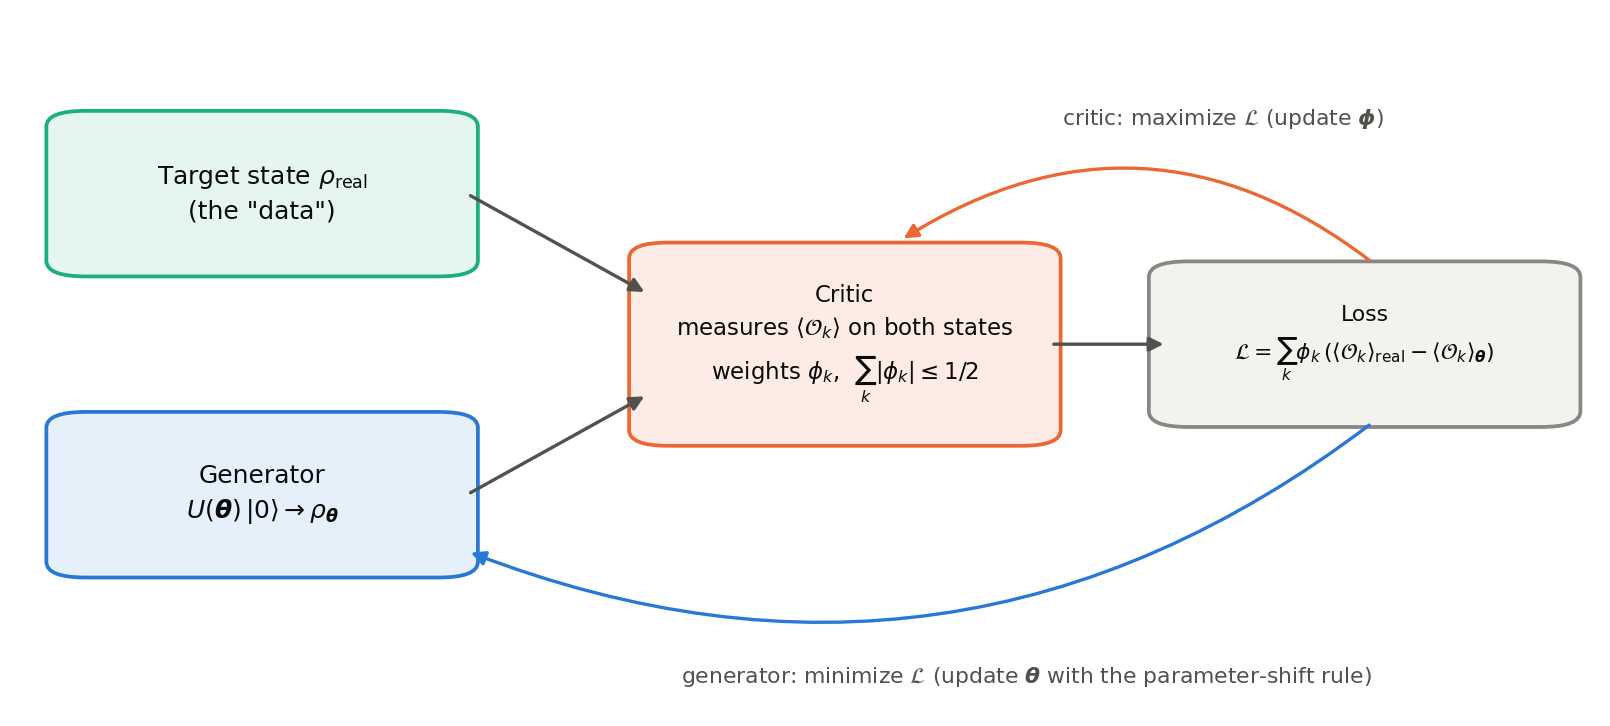

This kind of critic is a simplified *Wasserstein* distance; we come back to it in Section 3.

In [ ]:
# The condition on the critic weights is given, you just need to know when to apply it.

RADIUS = 0.5  # bound on the critic weights: sum_k |phi_k| <= RADIUS


def project_to_l1_ball(v: np.ndarray, radius: float = 1.0) -> np.ndarray:
    """Exact Euclidean projection onto the L1-ball: min ||w - v||_2 subject to ||w||_1 <= radius (Duchi et al., 2008)."""
    if np.sum(np.abs(v)) <= radius:
        return v
    u = np.sort(np.abs(v))[::-1]
    sv = np.cumsum(u)
    rho = np.where(u > (sv - radius) / (np.arange(len(u)) + 1))[0][-1]
    theta = (sv[rho] - radius) / (rho + 1)
    return np.sign(v) * np.maximum(np.abs(v) - theta, 0)


### Warm-up: a one-qubit QGAN
Complete the next cell: train the generator $R_Z(\theta_2) R_Y(\theta_1)|0\rangle$ to reproduce a one-qubit target state, with a critic that measures $X$, $Y$ and $Z$.
The generator gradient uses the **parameter-shift rule**, exact for gates $e^{-i\theta P/2}$ with $P$ a Pauli operator:
$$\frac{\partial \langle \mathcal{O} \rangle}{\partial \theta_j} = \frac{\langle \mathcal{O} \rangle_{\boldsymbol{\theta} + \frac{\pi}{2}\mathbf{e}_j} - \langle \mathcal{O} \rangle_{\boldsymbol{\theta} - \frac{\pi}{2}\mathbf{e}_j}}{2}$$
Sections 3 and 4 use exactly the same algorithm for a 6-qubit many-body state.

*Try it:* set different `POOL = ...`. Why does the fidelity reach 1 for some cases but no others?

*Try it*, keep the generator state fixed and run only the critic's projected gradient ascent. Then replace `project_to_l1_ball` with a projection onto the Euclidean ball $\|\boldsymbol{\phi}\|_2 \le 1/2$ (just rescale: `v * min(1, RADIUS / np.linalg.norm(v))`). Show that the critic then converges to $\frac{1}{2}\|\mathbf{v}_{\text{real}} - \mathbf{v}_{\boldsymbol{\theta}}\|_2$, which equals the trace distance between the two states (the exact Wasserstein-1 distance for one qubit), while the $\ell_1$ critic only reaches $\frac{1}{2}\max_k |\Delta_k|$. Section 3 explains what this simplification costs for many qubits.

*References:* Goodfellow et al. (2014), *Generative adversarial nets*, NeurIPS 27. · Lloyd & Weedbrook (2018), *Quantum generative adversarial learning*, Phys. Rev. Lett. 121, 040502.

In [ ]:
# Section 0: One-qubit warm-up QGAN

POOL = ...  # observables measured by the critic (try different POOLs = ['Z'], ['X', 'Y'], ...)


# The "data": a fixed one-qubit target state, R_Z(0.7) R_Y(1.2)|0> up to a global phase
toy_target = Statevector([np.cos(0.6), np.exp(0.7j) * np.sin(0.6)])


def toy_state(x: np.ndarray) -> Statevector:
    """TODO: return the generator output R_Z(x[1]) R_Y(x[0]) |0>."""
    raise NotImplementedError("TODO: toy_state")


def toy_expectations(x: np.ndarray) -> np.ndarray:
    """TODO: return the array of <P> for every Pauli label P in POOL (hint: SparsePauliOp('X'))."""
    raise NotImplementedError("TODO: toy_expectations")


def train_toy_qgan(
    x0: np.ndarray, steps: int = 60, lr_g: float = 2.0, lr_d: float = 0.5
) -> Tuple[np.ndarray, List[float]]:
    """TODO: adversarial training; return (final parameters, fidelity with toy_target after every step).
    Each step: gradient ascent of the critic weights followed by project_to_l1_ball(..., RADIUS), then gradient
    descent of the generator parameters with the parameter-shift rule."""
    raise NotImplementedError("TODO: train_toy_qgan")


# TODO: train from x0 = [0.1, 0.1] with different pools, and plot the different fidelities curves against the step.
# Can you explain the differences you observe?

---
## Section 1: The Target — Ground State of the Critical Ising Chain

The 1D Transverse Field Ising Model (TFIM) with open boundary conditions across $N$ sites is:
$$H = -J \sum_{i=0}^{N-2} Z_i Z_{i+1} - h \sum_{i=0}^{N-1} X_i$$
At $h/J = 1$ the chain sits at a quantum phase transition (the critical point) between an ordered phase ($h < J$) and a disordered phase ($h > J$). $H$ commutes with the global spin-flip (parity) operator $\Pi = \bigotimes_{i} X_i$, and its ground state has $\Pi = +1$; Section 2 uses this.

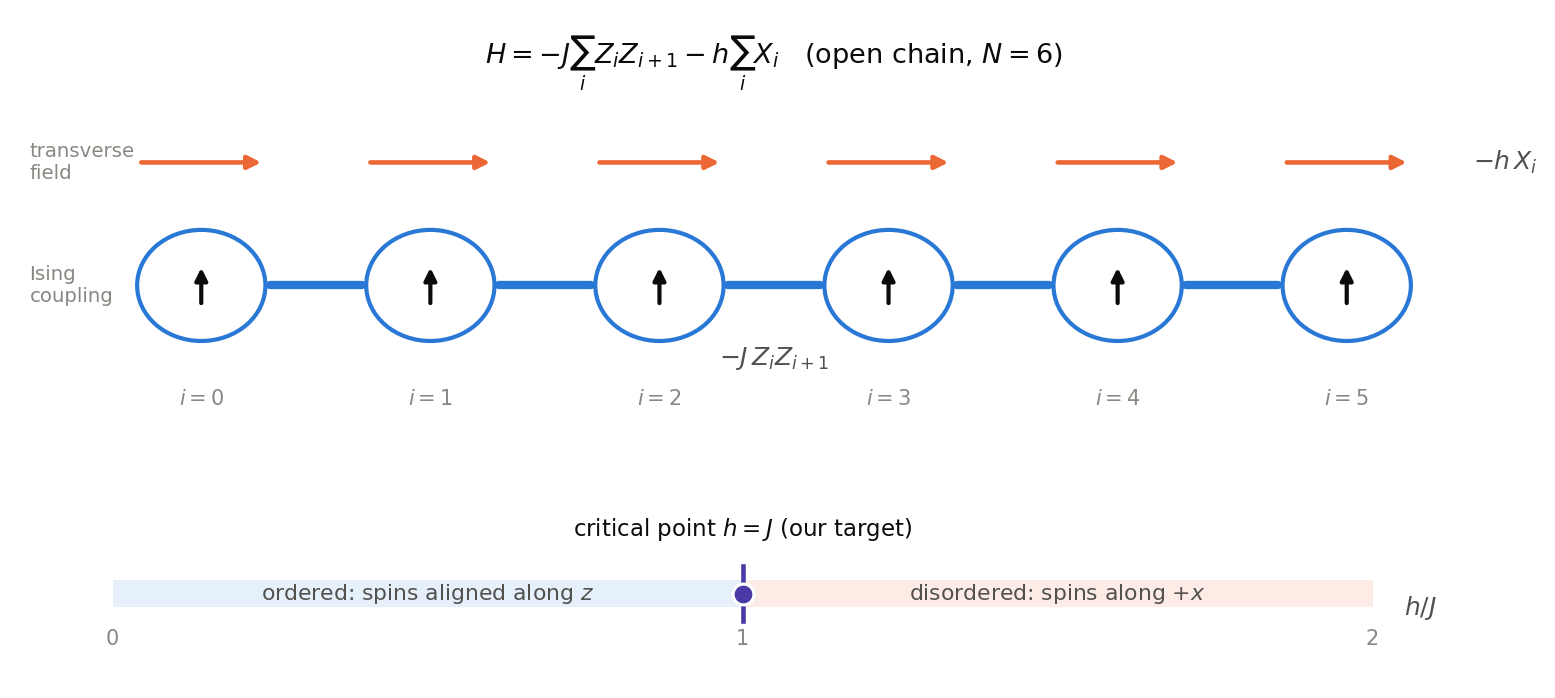

### Objectives
1. Construct the critical TFIM Hamiltonian ($J=1.0, h=1.0$) with open boundaries.
2. Calculate the exact ground state $|\psi_0\rangle$ and ground energy $E_0$ via exact diagonalization.
3. Construct the local observable pool $\mathcal{S} = \{ X_i \}_{i=0}^{N-1} \cup \{ Z_i Z_{i+1} \}_{i=0}^{N-2}$ of size $M = 2N - 1$.
4. Calculate the exact target expectation values $\mathbf{v}_{\text{real}}$ and the half-chain von Neumann entanglement entropy $S(\rho_A) = -\operatorname{Tr}[\rho_A \log_2 \rho_A]$.

> **Qubit ordering:** Qiskit is little-endian — in a Pauli label the *rightmost* character acts on qubit 0 (`'XIII'` is $X_3$, not $X_0$).

*Reference:* Pfeuty (1970), *The one-dimensional Ising model with a transverse field*, Ann. Phys. 57, 79.

In [ ]:
# Section 1: Exact TFIM Ground State Baseline and Local Observable Pool


def build_tfim_hamiltonian(num_qubits: int, J: float = 1.0, h: float = 1.0) -> SparsePauliOp:
    """TODO: return the open-chain H = -J sum_i Z_i Z_{i+1} - h sum_i X_i (hint: SparsePauliOp.from_sparse_list)."""
    raise NotImplementedError("TODO: build_tfim_hamiltonian")


def compute_exact_ground_state(hamiltonian: SparsePauliOp) -> Tuple[float, Statevector]:
    """TODO: return (E_0, |psi_0>) by exact diagonalization."""
    raise NotImplementedError("TODO: compute_exact_ground_state")


def construct_observable_pool(num_qubits: int) -> List[SparsePauliOp]:
    """TODO: return the pool [X_0, ..., X_{N-1}, Z_0 Z_1, ..., Z_{N-2} Z_{N-1}] (in this order)."""
    raise NotImplementedError("TODO: construct_observable_pool")


def compute_von_neumann_entropy(state: Statevector, subsystem_qubits: List[int]) -> float:
    """TODO: return S(rho_A) = -Tr[rho_A log2 rho_A] (bits) for A = subsystem_qubits.
    Hint: partial_trace(state, qargs) traces OUT the qubits listed in qargs."""
    raise NotImplementedError("TODO: compute_von_neumann_entropy")


N_QUBITS = 6
H_tfim = build_tfim_hamiltonian(N_QUBITS, J=1.0, h=1.0)
e_exact, psi_exact = compute_exact_ground_state(H_tfim)
obs_pool = construct_observable_pool(N_QUBITS)
v_real = np.array([float(psi_exact.expectation_value(op).real) for op in obs_pool])
subsystem_A = list(range(N_QUBITS // 2))
entropy_real = compute_von_neumann_entropy(psi_exact, subsystem_A)

# Checks
assert np.isclose(e_exact, -7.29623, atol=1e-5), "E_0 should be -7.29623 for N = 6 and J = h = 1"
assert len(obs_pool) == 2 * N_QUBITS - 1, "The pool should contain 2N - 1 observables"
assert np.isclose(compute_von_neumann_entropy(Statevector([1, 0, 0, 1] / np.sqrt(2)), [0]), 1.0), (
    "A Bell pair has 1 bit"
)

---
## Section 2: $\mathbb{Z}_2$ Parity-Preserving Quantum Generator Ansatz

Unconstrained "hardware-efficient" circuits ignore the symmetries of $H$ and explore the whole Hilbert space $(\mathbb{C}^2)^{\otimes N}$. Since $[H, \Pi] = 0$ and the ground state has $\Pi = +1$, we build the generator so that $[U_G(\boldsymbol{\theta}), \Pi] = 0$: the search then stays inside the physical parity sector.

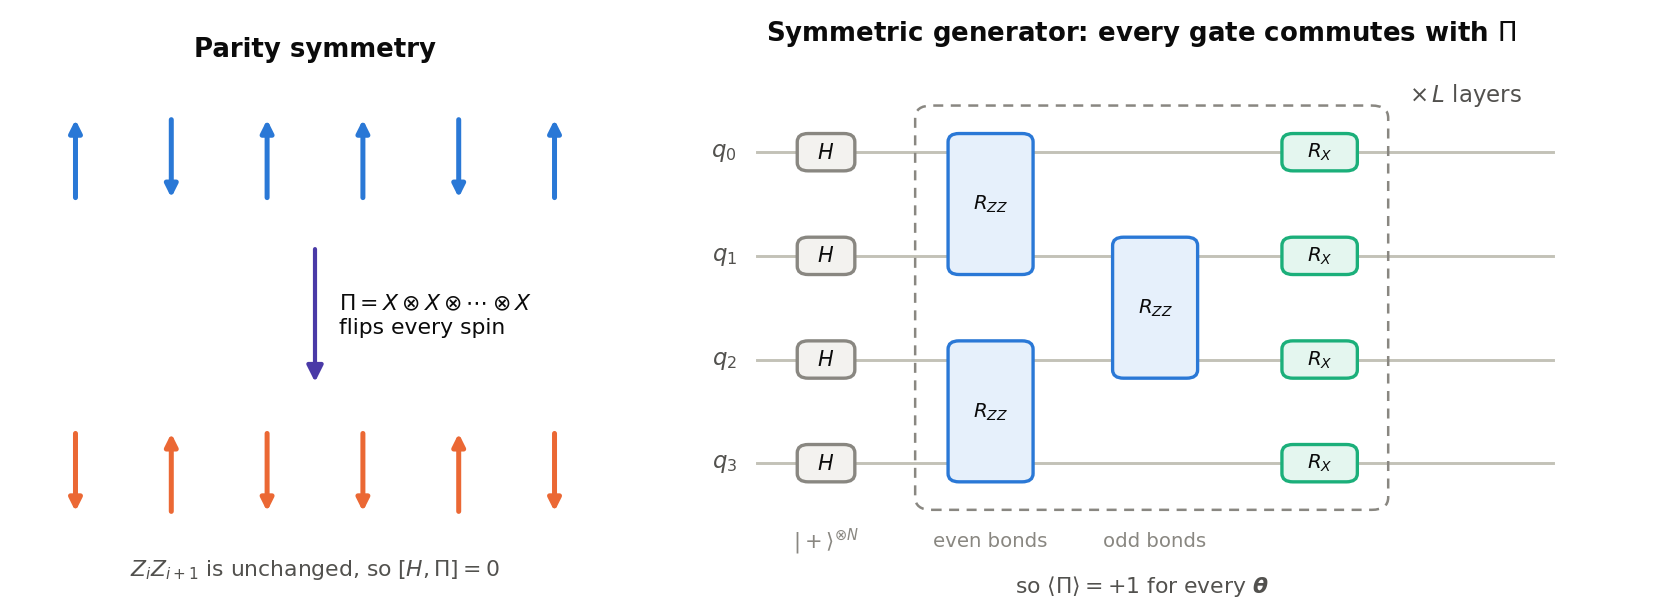

### Mathematical Commutation Proof
The ground state $|\psi_0\rangle$ belongs to the positive parity eigenspace $\Pi |\psi_0\rangle = +|\psi_0\rangle$, where $\Pi = \bigotimes_{i=0}^{N-1} X_i$.
1. **Initial State:** Starting in $|+\rangle^{\otimes N} = H^{\otimes N} |0\rangle^{\otimes N}$ guarantees $\Pi |+\rangle^{\otimes N} = +|+\rangle^{\otimes N}$.
2. **Single-Qubit Rotations:** $R_X(\theta) = \exp(-i \frac{\theta}{2} X)$ commutes with $X$:
   $$[R_X(\theta), X] = 0 \implies \left[\bigotimes_{i} R_X(\theta_i), \Pi\right] = 0$$
3. **Two-Qubit Interactions:** $R_{ZZ}(\theta) = \exp(-i \frac{\theta}{2} Z_i Z_{i+1})$. Under parity conjugation:
   $$\Pi (Z_i Z_{i+1}) \Pi^\dagger = (X_i Z_i X_i) (X_{i+1} Z_{i+1} X_{i+1}) = (-Z_i)(-Z_{i+1}) = Z_i Z_{i+1}$$
   Therefore, $[R_{ZZ}(\theta), \Pi] = 0$.

By induction, any circuit composed of $R_X$ and $R_{ZZ}$ layers acting on $|+\rangle^{\otimes N}$ strictly preserves $\langle \Pi \rangle = +1.0$ for all parameter values $\boldsymbol{\theta}$.

*Implementation note:* the $R_{ZZ}$ gates of one layer commute with each other, so we apply them on the even bonds first and then on the odd bonds — the same unitary with a shallower circuit.

In [ ]:
# Section 2: Symmetry-Preserving Ansatz Generator Circuit and Parity Verification


def create_z2_symmetric_generator(num_qubits: int, num_layers: int) -> Tuple[QuantumCircuit, ParameterVector]:
    """TODO: return (circuit, parameters): H on every qubit, then num_layers x [R_ZZ on every bond (i, i+1),
    R_X on every qubit]. One ParameterVector of length (2N - 1) * num_layers; theta[0] must be the first-layer
    R_ZZ angle on bond (0, 1)."""
    raise NotImplementedError("TODO: create_z2_symmetric_generator")


def test_parity_conservation(qc: QuantumCircuit, theta_params: ParameterVector, samples: int = 5) -> bool:
    """TODO Tests that <Pi> == 1.0 for random parameter values."""
    raise NotImplementedError("TODO: create a parity test")


gen_circuit, theta_params = create_z2_symmetric_generator(N_QUBITS, num_layers=3)
assert len(theta_params) == (2 * N_QUBITS - 1) * 3, "Unexpected number of parameters"
assert test_parity_conservation(gen_circuit, theta_params), "Parity conservation violated!"
print(f"Generator created: {len(theta_params)} parameters, depth {gen_circuit.depth()}")
print("Parity test PASSED: <Pi> = +1 for random parameter values")

---
## Section 3: The Wasserstein Critic & Parameter-Shift Training

### The critic as a restricted Wasserstein distance
The quantum Wasserstein distance of order 1 compares two states through all "smooth" observables. By the quantum Kantorovich–Rubinstein duality:
$$\mathcal{W}_1(\rho_{\text{real}}, \rho_G(\boldsymbol{\theta})) = \max_{\|D\|_{L} \le 1} \operatorname{Tr}\left[ D \left( \rho_{\text{real}} - \rho_G(\boldsymbol{\theta}) \right) \right]$$
where $\|D\|_{L}$ is the quantum Lipschitz constant (how much $\langle D\rangle$ can change when a single qubit is changed). We restrict the critic to our local pool:
$$D_{\boldsymbol{\phi}} = \sum_{k=1}^M \phi_k \mathcal{O}_k, \quad \text{subject to } \|\boldsymbol{\phi}\|_1 = \sum_{k=1}^M |\phi_k| \le \tfrac{1}{2}$$
In this normalization a single Pauli operator has $\|X_i\|_L = \|Z_i Z_{i+1}\|_L = 2$, so by the triangle inequality $\|D_{\boldsymbol{\phi}}\|_L \le 2\|\boldsymbol{\phi}\|_1$ and the bound $1/2$ guarantees $\|D_{\boldsymbol{\phi}}\|_L \le 1$. This is a sufficient condition, not the exact one (see below). The adversarial saddle-point objective becomes:
$$\min_{\boldsymbol{\theta}} \max_{\|\boldsymbol{\phi}\|_1 \le 1/2} \mathcal{L}(\boldsymbol{\theta}, \boldsymbol{\phi}), \qquad \mathcal{L}(\boldsymbol{\theta}, \boldsymbol{\phi}) = \sum_{k=1}^M \phi_k \left( \langle \mathcal{O}_k \rangle_{\text{real}} - \langle \mathcal{O}_k \rangle_{\boldsymbol{\theta}} \right)$$
For a fixed generator, the best critic puts all its weight on the worst-matched observable, so its value is $\tfrac{1}{2}\max_k |\langle \mathcal{O}_k \rangle_{\text{real}} - \langle \mathcal{O}_k \rangle_{\boldsymbol{\theta}}|$, a lower bound on $\mathcal{W}_1$. This is the number we monitor during training. Because the critic weights are bounded, the game cannot diverge, although alternating updates can oscillate.

### What the $\ell_1$ bound costs
The Lipschitz constant only adds up the weights of observables acting on the **same qubit**, $\|D_{\boldsymbol{\phi}}\|_L \le 2 \max_i \sum_{k \ni i} |\phi_k|$. So a valid Wasserstein critic can spend a budget of $1/2$ on *every* qubit, while our $\ell_1$ bound makes all $M$ observables share a *single* budget of $1/2$ (Section 0 showed the one-qubit version of this).
* **Smaller value:** if every qubit has the same error $\delta$ in $\langle X_i\rangle$, the $\ell_1$ critic finds $\tfrac{1}{2}\delta$, but the valid critic $\tfrac{1}{2}\sum_i X_i$ finds $\tfrac{1}{2}N\delta$. Our monitored value measures the *worst local* error, not the total one.
* **Sparser feedback:** the best $\ell_1$ critic puts its weight on one or two observables, so each generator step corrects only those.
* **Same solution:** both critics vanish only when *all* pool expectation values match, so the generator learns the same target. We use $\ell_1$ because its projection and best critic are simple to compute.

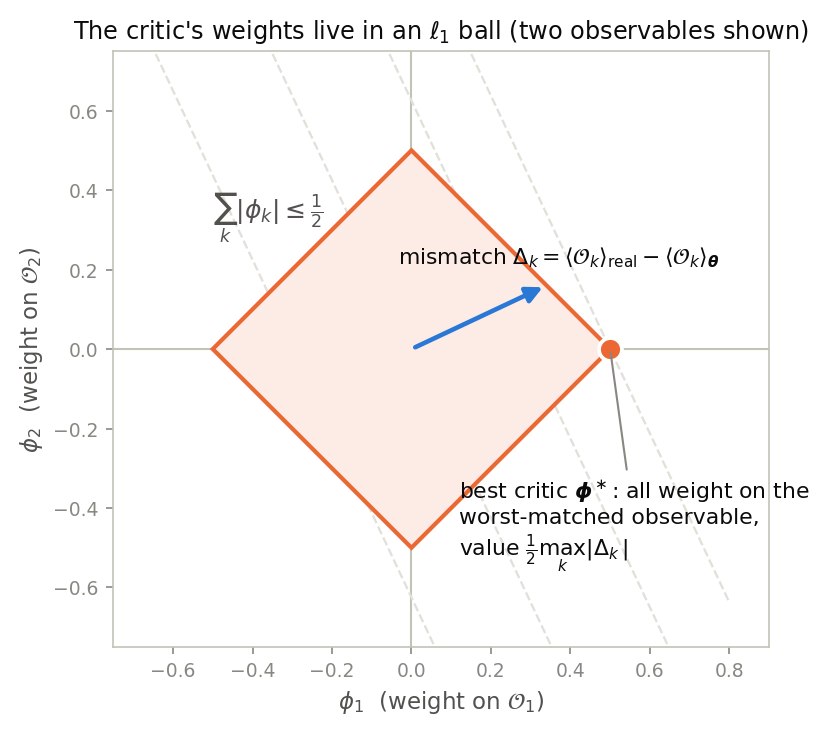

### Optimization Algorithms
1. **Discriminator Projected Gradient Ascent:**
   The discriminator maximizes $\mathcal{L}_D(\boldsymbol{\phi}) = \boldsymbol{\phi}^T (\mathbf{v}_{\text{real}} - \mathbf{v}_{\boldsymbol{\theta}})$ and is kept inside the $\ell_1$-ball of radius $1/2$ by the exact Euclidean projection `project_to_l1_ball` (defined in Section 0):
   $$\boldsymbol{\phi}^{(t+1)} = \mathrm{Proj}_{\|\cdot\|_1 \le 1/2}\left( \boldsymbol{\phi}^{(t)} + \eta_D (\mathbf{v}_{\text{real}} - \mathbf{v}_{\boldsymbol{\theta}}) \right)$$
2. **Generator Analytic Parameter-Shift Descent:**
   Every parameter enters exactly one gate $e^{-i\theta_j P/2}$, so the exact gradient with respect to $\theta_j$ is evaluated without finite differences:
   $$\frac{\partial \langle \mathcal{O}_k \rangle}{\partial \theta_j} = \frac{\langle \mathcal{O}_k \rangle_{\boldsymbol{\theta} + \frac{\pi}{2}\mathbf{e}_j} - \langle \mathcal{O}_k \rangle_{\boldsymbol{\theta} - \frac{\pi}{2}\mathbf{e}_j}}{2}$$
   $$\nabla_{\boldsymbol{\theta}} \mathcal{L}_G = -\sum_{k=1}^M \phi_k \nabla_{\boldsymbol{\theta}} \langle \mathcal{O}_k \rangle_{\boldsymbol{\theta}}, \quad \boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} - \eta_G \nabla_{\boldsymbol{\theta}} \mathcal{L}_G$$

*Reference:* De Palma, Marvian, Trevisan & Lloyd (2021), *The quantum Wasserstein distance of order 1*, IEEE Trans. Inf. Theory 67, 6627.

In [ ]:
# Section 3: WQGANTrainer Implementation (exact statevector simulation)


class WQGANTrainer:
    """Adversarial W-QGAN optimization engine (exact statevector simulation)."""

    def __init__(
        self,
        circuit: QuantumCircuit,
        parameters: ParameterVector,
        observables: List[SparsePauliOp],
        v_real: np.ndarray,
        target_state: Statevector,
        radius: float = 0.5,
        seed: int = 42,
    ):
        self.circuit = circuit
        self.parameters = parameters
        self.observables = observables
        self.v_real = v_real
        self.target_state = target_state
        self.radius = radius
        self.num_params = len(parameters)
        self.num_obs = len(observables)

        rng = np.random.default_rng(seed)
        self.theta = rng.uniform(-0.1, 0.1, self.num_params)
        self.phi = np.zeros(self.num_obs)

    def evaluate_expectations(self, theta_vals: np.ndarray) -> np.ndarray:
        """TODO: return the array of <O_k> (one per observable) of the generator state for parameters theta_vals."""
        raise NotImplementedError("TODO: evaluate_expectations")

    def compute_generator_gradient(self, theta_vals: np.ndarray, phi_weights: np.ndarray) -> np.ndarray:
        """TODO: return dL/dtheta (length self.num_params) using the parameter-shift rule."""
        raise NotImplementedError("TODO: compute_generator_gradient")

    def train_step(self, lr_g: float = 2.0, lr_d: float = 0.5) -> Tuple[float, float, float]:
        """TODO: one adversarial step (critic update, then generator update). Return, at the NEW parameters,
        (best-critic value = W1 lower bound, fidelity with self.target_state, norm of the generator gradient)."""
        raise NotImplementedError("TODO: train_step")


# Check the parameter-shift gradient against a finite difference
check_trainer = WQGANTrainer(gen_circuit, theta_params, obs_pool, v_real, psi_exact, seed=0)
weights = np.random.default_rng(1).normal(size=len(obs_pool))
grad = check_trainer.compute_generator_gradient(check_trainer.theta, weights)
e0, eps = np.eye(len(theta_params))[0], 1e-6
finite_diff = (
    -weights
    @ (
        check_trainer.evaluate_expectations(check_trainer.theta + eps * e0)
        - check_trainer.evaluate_expectations(check_trainer.theta - eps * e0)
    )
    / (2 * eps)
)
assert np.isclose(grad[0], finite_diff, atol=1e-6), "Parameter-shift gradient disagrees with finite differences"
print("WQGANTrainer engine initialized: parameter-shift gradient agrees with finite differences.")

---
## Section 4: Training Execution & Barren Plateau Ablation

### Experiments to Perform
Write the code for these three experiments; the cells below only sketch the functions you need.
1. **Adversarial Training Loop:** Run the minimax optimization and follow the best-critic value ($\mathcal{W}_1$ lower bound) and the state fidelity $\mathcal{F}$.
2. **Entanglement Entropy Recovery:** Compare the half-chain entropy of the trained state with the exact one. At the critical point, conformal field theory predicts that the half-chain entropy of an open chain grows logarithmically with the system size, $S(N/2) \simeq \frac{c}{6}\log_2 N + \text{const}$, with central charge $c = 1/2$. Check this with exact diagonalization for several $N$; small chains show visible finite-size corrections.
3. **Barren Plateau Mitigation:** For random parameters, gradients of *global* costs, such as the fidelity-type projector $\vert{}0^{\otimes N}\rangle\langle 0^{\otimes N}\vert{}$, vanish exponentially with $N$, even for shallow circuits, whereas gradients of *local* observables do not. Quantify the variance of the gradient $\operatorname{Var}_{\boldsymbol{\theta}}[\partial_{\theta_0} \langle O \rangle]$ as a function of qubit count $N \in \{4, 6, 8, 10\}$ comparing:
   * **Local Observable Loss (Wasserstein):** $O_{\text{local}} = X_0$
   * **Global Observable Loss (Fidelity/Projector):** $O_{\text{global}} = \vert{}0^{\otimes N}\rangle\langle 0^{\otimes N}\vert{}$

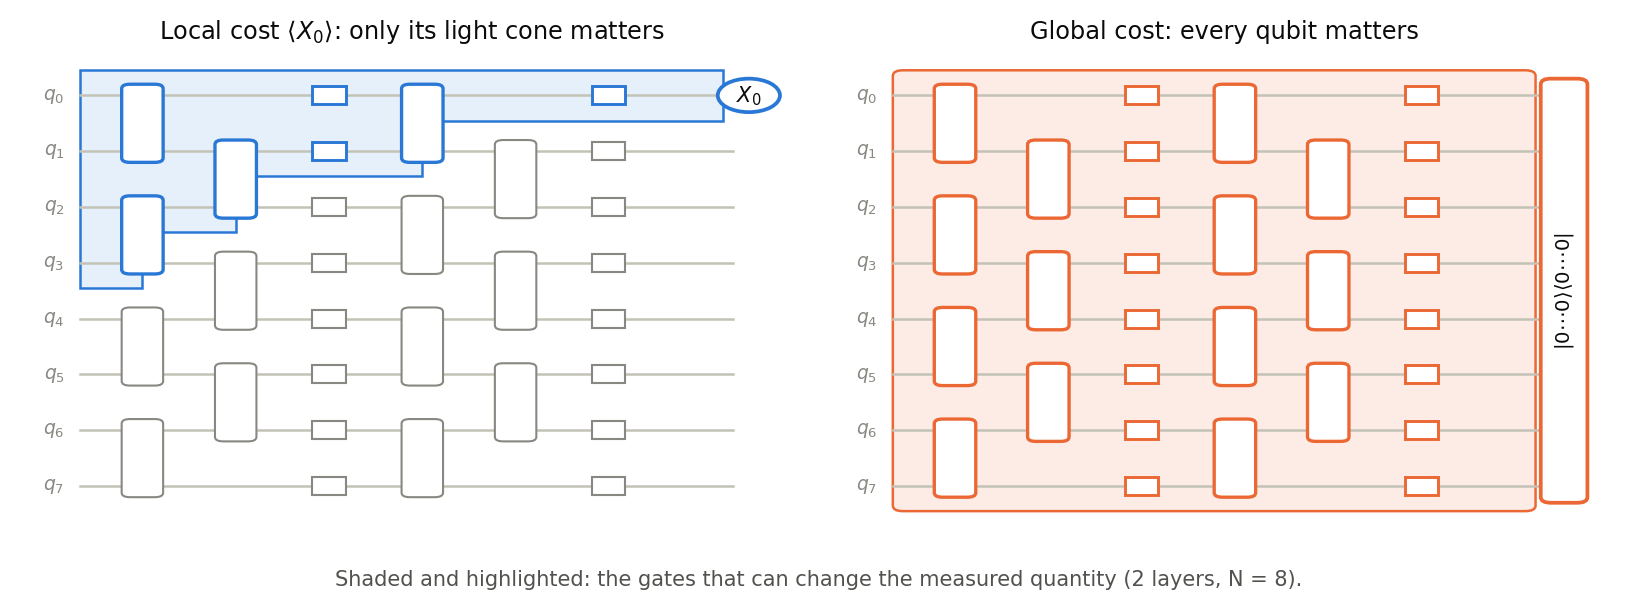

*References:* Calabrese & Cardy (2004), *Entanglement entropy and quantum field theory*, J. Stat. Mech. P06002. · Cerezo et al. (2021), *Cost function dependent barren plateaus in shallow parametrized quantum circuits*, Nat. Commun. 12, 1791.

In [ ]:
# Section 4a: Training Execution and Entanglement Entropy


def run_training(
    trainer: WQGANTrainer, num_epochs: int, lr_g: float = 2.0, lr_d: float = 0.5, log_every: int = 50
) -> Tuple[List[float], List[float]]:
    """TODO: call trainer.train_step num_epochs times; return (W1 lower bound history, fidelity history)."""
    raise NotImplementedError("TODO: run_training")


# TODO:
#  1. create a WQGANTrainer called `trainer` for gen_circuit (Track B reuses trainer.theta);
#  2. train it for about 300 epochs (lr_g = 2.0 and lr_d = 0.5 work well) and plot both histories on a log scale;
#  3. compare the half-chain entropy of the trained state with entropy_real.

In [ ]:
# Section 4b: CFT Check with Exact Diagonalization and Barren Plateau Ablation


def half_chain_entropy_ed(n: int) -> float:
    """TODO: half-chain entropy (bits) of the critical TFIM ground state on n sites.
    Hint: scipy.sparse.linalg.eigsh on H.to_matrix(sparse=True) handles n up to ~14 quickly."""
    raise NotImplementedError("TODO: half_chain_entropy_ed")


def fit_central_charge(sizes: List[int], entropies: List[float]) -> float:
    """TODO: return c from S(N/2) = (c/6) log2 N + const."""
    raise NotImplementedError("TODO: fit_central_charge")


def gradient_variance(num_qubits: int, num_layers: int, cost: str, num_samples: int, rng: np.random.Generator) -> float:
    """TODO: variance over random parameters of d<C>/d theta_0 (parameter-shift rule), for cost = "local"
    (C = X_0) or cost = "global" (C = |0...0><0...0|)."""
    raise NotImplementedError("TODO: gradient_variance")


# TODO:
#  1. compute the half-chain entropy for N = 6, 8, ..., 14 and fit the central charge (CFT: c = 0.5);
#  2. compare the gradient variance of the local and global costs for N = 4, 6, 8, 10
#     (2 layers, about 200 samples) and plot both on a log scale.

---
## Advanced Extension Track A: Thermal Mixed States via Thermofield Double Purification

### Theoretical Formalism
At finite inverse temperature $\beta = 1/(k_B T)$, many-body quantum states are non-pure statistical ensembles described by the density matrix:
$$\rho(\beta) = \frac{e^{-\beta H}}{\mathcal{Z}}, \quad \mathcal{Z} = \operatorname{Tr}\left[e^{-\beta H}\right]$$
A unitary circuit acting on a pure input state always produces a pure state, so preparing $\rho(\beta)$ requires auxiliary qubits. By Thermofield Dynamics, we double the Hilbert space to $\mathcal{H}_S \otimes \mathcal{H}_A$ using an ancilla register $A \cong S$ ($2N$ qubits total).
The pure **Thermofield Double (TFD)** state is:
$$\vert{}\psi_{\text{TFD}}(\beta)\rangle = \frac{1}{\sqrt{\mathcal{Z}}} \sum_{n} e^{-\beta E_n / 2} \vert{}n\rangle_S \vert{}\tilde{n}\rangle_A$$
Tracing out the ancilla register $A$ yields the exact thermal Gibbs state:
$$\operatorname{Tr}_A\left[ \vert{}\psi_{\text{TFD}}(\beta)\rangle\langle\psi_{\text{TFD}}(\beta)\vert{} \right] = \rho(\beta)$$

### Building the TFD Circuit
Bell pairs between $S_i$ and $A_i$ give the TFD state at infinite temperature ($\beta = 0$, $\rho_S = \mathbb{I}/2^N$). Gates acting only on $S$ can never change the eigenvalues of $\rho_S$, so the circuit must also contain gates that **couple each $S_i$ to its partner $A_i$** (here $R_{XX}$ and $R_{ZZ}$), interleaved with TFIM-like layers on $S$ and on $A$.

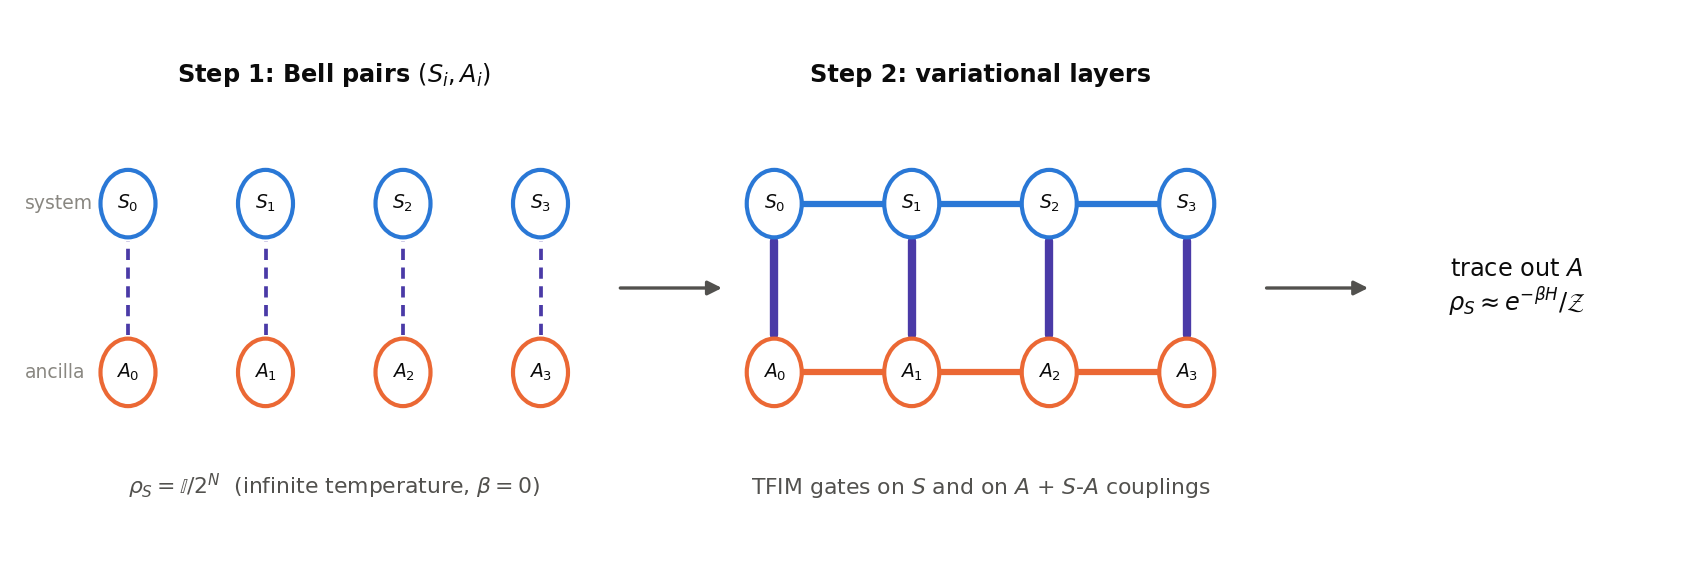

### Discriminator Adaptation for Mixed States
The discriminator pool acts strictly on the physical system register $S$:
$$\mathcal{O}_k^{(S)} \equiv \mathcal{O}_k \otimes I_A^{\otimes N}$$
This allows the W-QGAN to train on thermal expectation values without measuring the ancilla qubits. Matching these few expectation values does not by itself guarantee the thermal state; a simple remedy is to also minimize the free energy $F(\rho) = \operatorname{Tr}[\rho H] + \beta^{-1}\operatorname{Tr}[\rho \ln \rho]$, whose unique minimum is $\rho(\beta)$.

*Reference:* Wu & Hsieh (2019), *Variational thermal quantum simulation via thermofield double states*, Phys. Rev. Lett. 123, 220502.

In [ ]:
# Extension Track A: Thermal Gibbs State & Thermofield Double Architecture


def compute_thermal_gibbs_state(hamiltonian: SparsePauliOp, beta: float) -> DensityMatrix:
    """TODO: return rho(beta) = exp(-beta H) / Z."""
    raise NotImplementedError("TODO: compute_thermal_gibbs_state")


def create_tfd_generator(num_sys_qubits: int, num_layers: int) -> Tuple[QuantumCircuit, ParameterVector]:
    """TODO: return (circuit, parameters) for a 2N-qubit TFD ansatz with S = qubits 0..N-1 and A = qubits N..2N-1:
    Bell pairs (S_i, A_i), then num_layers layers of TFIM-like gates on S and on A plus gates that couple S_i to A_i.
    Use each parameter in exactly one gate."""
    raise NotImplementedError("TODO: create_tfd_generator")


# Verify Mixed Thermal State for N = 4 at beta = 1.0
N_SYS = 4
BETA = 1.0
H_sys = build_tfim_hamiltonian(N_SYS, J=1.0, h=1.0)
rho_gibbs = compute_thermal_gibbs_state(H_sys, beta=BETA)
tfd_qc, tfd_params = create_tfd_generator(N_SYS, num_layers=2)
assert np.isclose(rho_gibbs.purity().real, 0.3838, atol=1e-4), "Tr(rho^2) should be 0.3838 for N = 4, beta = 1"

# Check: the reduced state of S must change with the parameters (without S-A couplings it stays I / 2^N)
rng = np.random.default_rng(7)
purities = []
for _ in range(3):
    vals = rng.uniform(-np.pi, np.pi, len(tfd_params))
    sv = Statevector.from_instruction(tfd_qc.assign_parameters(dict(zip(tfd_params, vals))))
    purities.append(partial_trace(sv, list(range(N_SYS, 2 * N_SYS))).purity().real)
assert np.ptp(purities) > 1e-3, "rho_S does not depend on the parameters: the circuit cannot leave beta = 0"

# TODO: train the TFD generator so that rho_S approaches rho_gibbs (see the free-energy remark above).

---
## Advanced Extension Track B: IBM Quantum Deployment (Free-Tier Budget Strategy)

### The Free Tier Hardware Operational Constraint
Each team member's IBM Quantum Open Plan account includes a small free allocation of QPU time (10 minutes at the time of writing — check the current terms). Allocations are per account.
* **Anti-Pattern:** Do NOT run iterative training loops on the physical QPU. A 30-epoch training loop with parameter-shift gradients requires thousands of circuit executions, which would exhaust your entire team budget and suffer from queuing delays.
* **The Inference / Zero-In-The-Loop Paradigm:**
  1. Train your W-QGAN generator to convergence locally with the simulator.
  2. Bind the optimal parameters $\boldsymbol{\theta}^*$ to the circuit.
  3. Transpile the circuit **for the chosen backend** (an "ISA" circuit: native gates and qubit connectivity) and map the observables onto the physical qubits with `apply_layout`.
  4. Package all pool observables $\mathcal{S}$ into a **single Primitive Unified Bloc (PUB)** for Qiskit Runtime `EstimatorV2` and submit one job to an available QPU (select it with `service.least_busy(...)`; device names change over time).

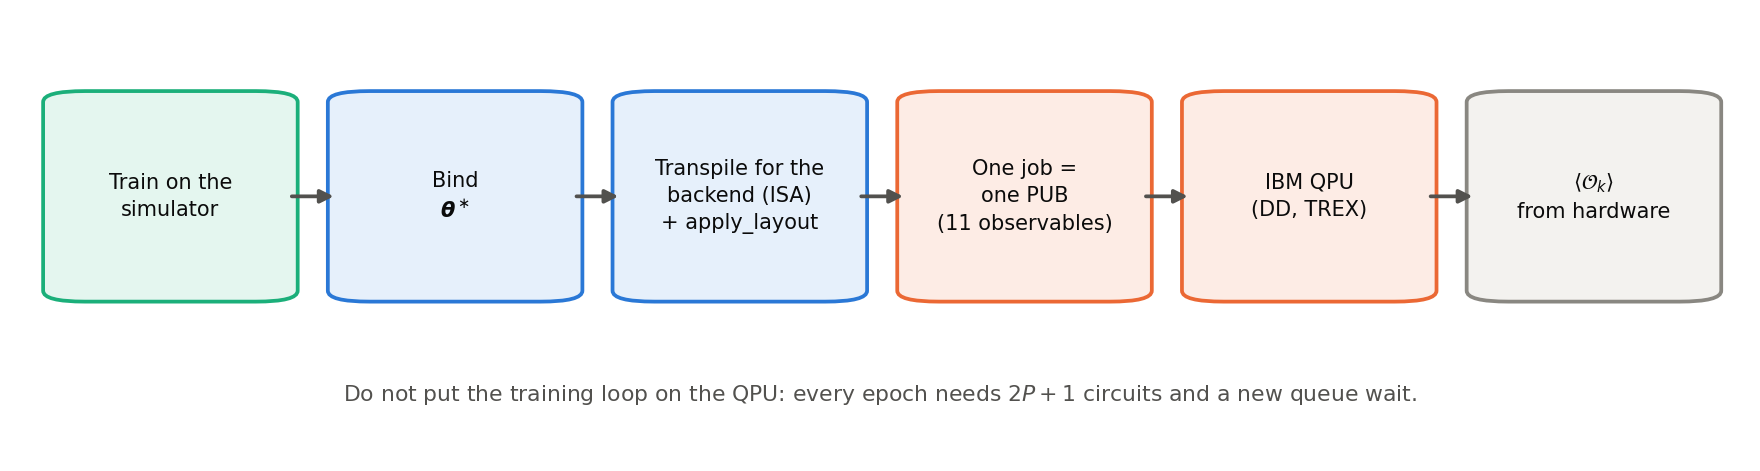

### Error Mitigation Requirements for Extension B
To claim full points in Track B, you must apply the following mitigation techniques in your Runtime configuration:
1. **PassManager Level 3 Optimization:** Routing and SWAP gate minimization for the heavy-hex topology.
2. **Dynamical Decoupling (DD):** Insert $XY4$ pulse sequences on idle qubits to mitigate environmental dephasing.
3. **Readout Mitigation (TREX):** Twirled readout error extinction to remove measurement bias.

*Useful APIs:* `QiskitRuntimeService(channel='ibm_quantum_platform')`, `service.least_busy(...)`, `generate_preset_pass_manager(backend=...)`, `SparsePauliOp.apply_layout`, `EstimatorV2(mode=backend, options=...)` with `EstimatorOptions` (`resilience_level`, `dynamical_decoupling`), `job.usage()`. The fake backends in `qiskit_ibm_runtime.fake_provider` (e.g. `FakeFez`) run the same code locally.

*Reference:* van den Berg, Minev & Temme (2022), *Model-free readout-error mitigation for quantum expectation values*, Phys. Rev. A 105, 032620.

In [ ]:
# Extension Track B: IBM Quantum Deployment and Transpilation Pipeline
import warnings
from qiskit_ibm_runtime import EstimatorV2 as RuntimeEstimator
from qiskit_ibm_runtime.fake_provider import FakeFez

warnings.filterwarnings(
    "ignore", message="The EstimatorV2 class is deprecated"
)  # deprecated from qiskit-ibm-runtime 0.50


def prepare_hardware_pub(
    circuit: QuantumCircuit,
    optimal_theta: np.ndarray,
    param_vector: ParameterVector,
    observables: List[SparsePauliOp],
    backend,
) -> Tuple[QuantumCircuit, List[SparsePauliOp]]:
    """TODO: bind optimal_theta, transpile for `backend` (ISA circuit) and map the observables onto the physical
    qubits; return (isa_circuit, isa_observables)."""
    raise NotImplementedError("TODO: prepare_hardware_pub")


def estimate_on_backend(
    isa_circuit: QuantumCircuit, isa_observables: List[SparsePauliOp], backend, options: Optional[dict] = None
) -> np.ndarray:
    """TODO: run ONE Estimator job containing ONE PUB (isa_circuit, isa_observables); return the expectation values.
    With backend = FakeFez() it runs locally on a noisy simulator; with a real backend it uses your QPU time."""
    raise NotImplementedError("TODO: estimate_on_backend")


# TODO: rehearse locally with FakeFez() and compare with trainer.evaluate_expectations(trainer.theta);
#       then one team member submits the same PUB to a real backend, with the error mitigation listed above.

---
## Advanced Extension Track C: High-Performance JAX Acceleration

### Why Standard Python Loops are a Bottleneck
Evaluating parameter-shift gradients sequentially requires $2 \times p$ quantum circuit evaluations per iteration. For $N = 10$ and $p = 50$, this requires 100 circuit executions per step. In standard Python, interpreter overhead dominates.

### The JAX Acceleration Principle
Using JAX, the statevector is represented as an $N$-dimensional complex tensor of shape $(2, 2, \dots, 2)$. Using `jax.vmap`, all $2p$ parameter-shifted circuits can be executed in a single vectorized call (compiled with `jax.jit`), which typically gives large speedups. Measure yours against the `WQGANTrainer` of Section 3.

In [ ]:
# Extension Track C: JAX Tensor Vectorization Concept Scaffold

try:
    import jax

    jax.config.update("jax_enable_x64", True)  # double precision, like the Qiskit simulators
    import jax.numpy as jnp

    JAX_AVAILABLE = True
except ImportError:
    JAX_AVAILABLE = False

if JAX_AVAILABLE:
    sigma_x = jnp.array([[0.0, 1.0], [1.0, 0.0]], dtype=jnp.complex128)
    sigma_z = jnp.array([[1.0, 0.0], [0.0, -1.0]], dtype=jnp.complex128)
    identity = jnp.eye(2, dtype=jnp.complex128)

    def apply_rx_jax(state: jnp.ndarray, angle: float, qubit: int) -> jnp.ndarray:
        """TODO: apply R_X(angle) to `qubit` of `state`, a statevector stored as a tensor of shape (2,)*N.
        Hint: Qiskit's qubit q is tensor axis N-1-q (N = state.ndim)."""
        raise NotImplementedError("TODO: apply_rx_jax")

    # Check against Qiskit on a random 3-qubit state, for every qubit
    rng = np.random.default_rng(0)
    vec = rng.normal(size=8) + 1j * rng.normal(size=8)
    vec /= np.linalg.norm(vec)
    for q in range(3):
        qc_check = QuantumCircuit(3)
        qc_check.rx(0.7, q)
        jax_result = np.asarray(apply_rx_jax(jnp.asarray(vec).reshape(2, 2, 2), 0.7, q)).reshape(-1)
        assert np.allclose(jax_result, Statevector(vec).evolve(qc_check).data), f"Wrong qubit ordering for qubit {q}"
    print(
        "JAX is installed and apply_rx_jax is verified. Teams pursuing Track C should replace the parameter-shift loop with jax.vmap."
    )
else:
    print("JAX is not installed in this environment (for example on Intel Macs); Track C needs it.")

# TODO: write the generator in JAX (the R_ZZ layers are diagonal phases), vectorize the 2P shifted evaluations with
#       jax.vmap and jax.jit, check the gradient against WQGANTrainer.compute_generator_gradient and time both.

---
## Advanced Extension Track D: Learning Hamiltonian Unitary Dynamics $U(t) = e^{-i H t}$

### Theoretical Problem Formulation
Instead of generating a single target ray $\vert{}\psi_0\rangle \in \mathcal{H}$, the generator must learn an unknown unitary channel:
$$\mathcal{E}_t(\rho) = U(t) \rho U(t)^\dagger, \quad U(t) = \exp(-i H t)$$
for a quench duration $t = \tau$ under the critical TFIM Hamiltonian.
The objective is to train a parameterized unitary $V(\boldsymbol{\theta})$ to maximize average gate fidelity over the Haar measure:
$$\bar{\mathcal{F}}(U(\tau), V(\boldsymbol{\theta})) \equiv \int_{\text{Haar}} d\psi \, \left\vert{} \langle \psi \vert{} U^\dagger(\tau) V(\boldsymbol{\theta}) \vert{} \psi \rangle \right\vert{}^2 \to 1$$

Participants can choose between two approaches:
* **Option D1: Choi–Jamiołkowski Isomorphism Track (Channel–State Duality on $2N$ Qubits)**
* **Option D2: Product-State Input Batching Track (Ensemble Learning on $N$ Qubits)**

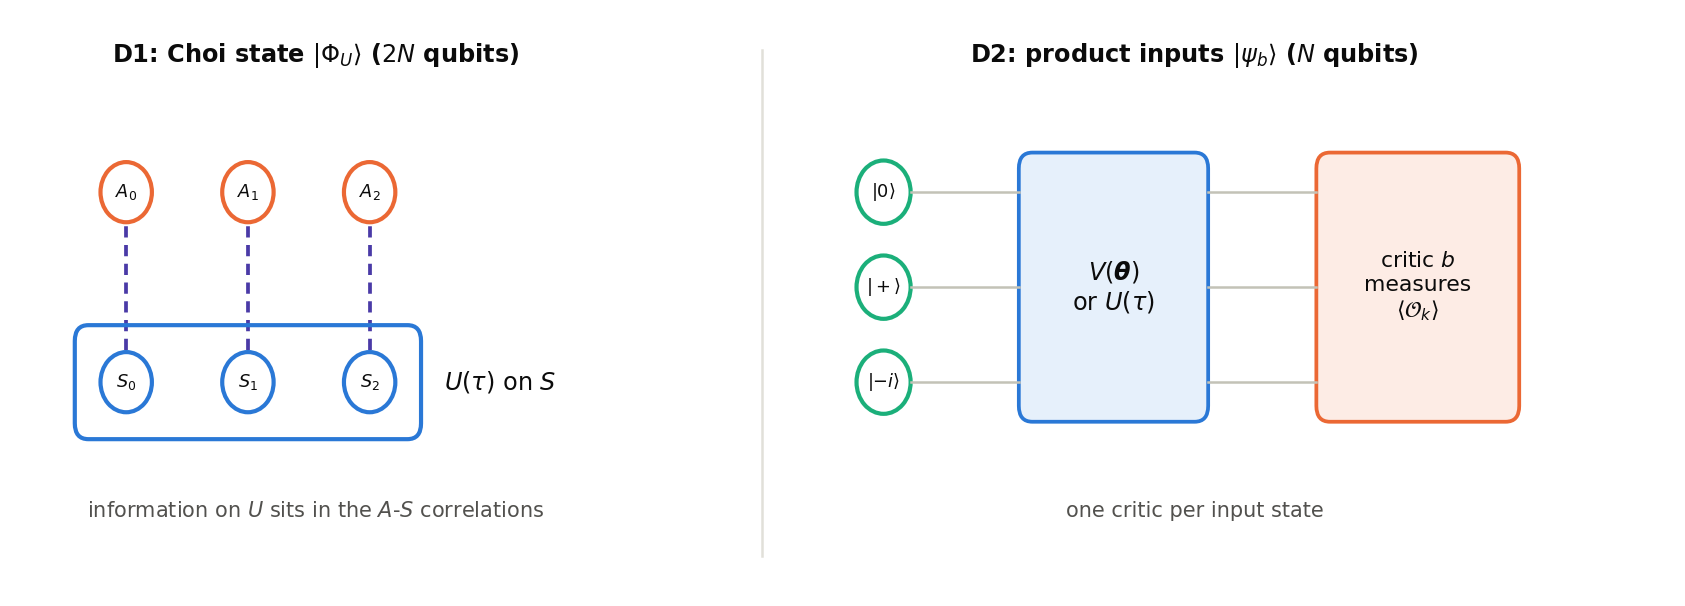

---

### Option D1: Choi–Jamiołkowski Isomorphism (Channel–State Formulation)
Any unitary channel $U$ on $N$ qubits corresponds to a maximally entangled pure state $\vert{}\Phi_U\rangle$ on $2N$ qubits ($\mathcal{H}_A \otimes \mathcal{H}_S$):
$$\vert{}\Phi_U\rangle = (\mathbb{I}_A \otimes U) \vert{}\Phi^+\rangle, \quad \vert{}\Phi^+\rangle = \bigotimes_{j=0}^{N-1} \frac{\vert{}00\rangle_{A_j S_j} + \vert{}11\rangle_{A_j S_j}}{\sqrt{2}}$$
* **Target Choi State:** $\vert{}\Phi_{U(\tau)}\rangle = (\mathbb{I}_A \otimes e^{-i H \tau}) \vert{}\Phi^+\rangle$
* **Generator Choi State:** $\vert{}\Phi_{V(\boldsymbol{\theta})}\rangle = (\mathbb{I}_A \otimes V(\boldsymbol{\theta})) \vert{}\Phi^+\rangle$
* **Entanglement-to-Gate Fidelity Relation:**
  $$F_e = \left\vert{} \langle \Phi_{U(\tau)} \vert{} \Phi_{V(\boldsymbol{\theta})} \rangle \right\vert{}^2 \implies \bar{\mathcal{F}}(U, V) = \frac{2^N F_e + 1}{2^N + 1}$$
* **Hint:** the reduced state of $\vert\Phi_U\rangle$ on $S$ alone (or on $A$ alone) is the same for every $U$, so the critic must measure observables acting on both registers.

In [ ]:
# Extension Track D1: Choi-Jamiołkowski State Generator (2N Qubits) ---
def create_choi_generator(num_sys_qubits: int, num_layers: int) -> Tuple[QuantumCircuit, ParameterVector]:
    """TODO: return (circuit, parameters): Bell pairs (A_i, S_i) with A = qubits 0..N-1 and S = qubits N..2N-1, then
    V(theta) on S made of num_layers layers [R_ZZ on neighbouring S qubits, R_X on every S qubit]."""
    raise NotImplementedError("TODO: create_choi_generator")


def compute_target_choi_state(hamiltonian: SparsePauliOp, tau: float) -> Statevector:
    """TODO: return (I_A (x) U_S)|Phi+> with U = exp(-i H tau), using the same registers as create_choi_generator."""
    raise NotImplementedError("TODO: compute_target_choi_state")


# Verification: N=3 Quench Simulation at tau = 0.5
N_DYN = 3
TAU = 0.5
H_dyn = build_tfim_hamiltonian(N_DYN, J=1.0, h=1.0)
target_choi_sv = compute_target_choi_state(H_dyn, tau=TAU)
choi_qc, choi_params = create_choi_generator(N_DYN, num_layers=2)
assert target_choi_sv.num_qubits == 2 * N_DYN and np.isclose(np.linalg.norm(target_choi_sv.data), 1.0), (
    "The Choi state lives on 2N qubits and must be normalized"
)


### Option D2: Product-State Input Batching (Ensemble Learning)
To avoid the $2N$-qubit overhead of the Choi representation, train on input states drawn from the products of single-qubit Pauli eigenstates $\{ \vert{}0\rangle, \vert{}1\rangle, \vert{}+\rangle, \vert{}-\rangle, \vert{}+i\rangle, \vert{}-i\rangle \}^{\otimes N}$. For $N \ge 2$ these $6^N$ states are *not* a 2-design, but they are enough to determine $U$.
* **Mini-Batch Objective:** In each epoch, sample a mini-batch of $B \ll 6^N$ input states $\{ \vert{}\psi_{\text{in}}^{(b)}\rangle \}_{b=1}^B$ and use **one critic per input state**:
  $$\mathcal{L}(\boldsymbol{\theta}, \boldsymbol{\phi}) = \frac{1}{B} \sum_{b=1}^B \sum_{k=1}^M \phi_k^{(b)} \left( \langle \psi_{\text{in}}^{(b)} \vert{} U^\dagger(\tau) \mathcal{O}_k U(\tau) \vert{} \psi_{\text{in}}^{(b)} \rangle - \langle \psi_{\text{in}}^{(b)} \vert{} V^\dagger(\boldsymbol{\theta}) \mathcal{O}_k V(\boldsymbol{\theta}) \vert{} \psi_{\text{in}}^{(b)} \rangle \right)$$
  (a single critic shared by all inputs only compares averaged outputs and cannot detect the error).
* **Hint:** every observable in $\{X_i, Z_i Z_{i+1}\}$ commutes with $\Pi$, so this pool cannot tell $V$ from $\Pi V$; add parity-odd observables such as $Z_i$.
* **Advantage:** Runs strictly on $N$ qubits, compatible with the IBM Quantum free allocation.

*Reference:* Nielsen (2002), *A simple formula for the average gate fidelity of a quantum dynamical operation*, Phys. Lett. A 303, 249.

In [ ]:
# Extension Track D2: Product Pauli-Eigenstate Mini-Batch Sampler (N Qubits) ---
def sample_pauli_eigenstate_circuit(num_qubits: int, rng: Optional[np.random.Generator] = None) -> QuantumCircuit:
    """TODO: return a circuit preparing a random product of the six Pauli eigenstates |0>, |1>, |+>, |->, |+i>, |-i>."""
    raise NotImplementedError("TODO: sample_pauli_eigenstate_circuit")


# Verification: N=3 Quench Simulation at tau = 0.5
N_DYN = 3
TAU = 0.5
H_dyn = build_tfim_hamiltonian(N_DYN, J=1.0, h=1.0)

print(
    f"Option D2 (Product inputs): Sampled Random Input Circuit Depth = {sample_pauli_eigenstate_circuit(N_DYN, np.random.default_rng(0)).depth()}"
)

---
## Advanced Extension Track E: Open problem!

If you have had time, to finish all above, understanding the concepts well to explain in a presentation in detail, preparing such presentation, etc... and still have some more time, this is for you!

Think of your own extension, and implement it to distinguish your group from the rest. The more ambitious the better! (If and LLM proposes an idea, it will most likely be the same for other groups, so try to not pick its first proposal hehe)

In [ ]:
# Extension Track E:


---
## Hackathon Evaluation Paradigm: On-Site Oral Presentation & Technical Defense

### Evaluation Structure
There is **no automated grading test suite**. Evaluation is conducted 100% on-site based on:
1. A **10-minute live slide presentation** and code walkthrough by the entire team.
2. A **5-minute technical Q&A / oral defense** with the academic jury.

---

### Oral Defense Probe Questions
Judges can ask similar questions during the presentation to verify genuine student comprehension:
1. *"Why does a global projector discriminator suffer from a barren plateau even at shallow circuit depth, and how does your local, bounded observable pool avoid it?"*
2. *"Prove algebraically why the two-qubit gate $R_{ZZ}(\theta)$ preserves $\mathbb{Z}_2$ spin-flip parity $\Pi = \bigotimes_{i=0}^{N-1} X_i$. Does $R_{YZ}(\theta)$ preserve it? Name a two-qubit rotation that breaks it."*
3. *"In the Thermofield Double purification (Track A), why is measuring observables exclusively on the physical system register $S$ equivalent to taking expectation values against the mixed Gibbs density matrix $\rho(\beta)$? Why does the circuit need gates that couple $S$ and $A$?"*
4. *"In Extension Track D, why does the pure Choi state $\vert{}\Phi_U\rangle$ in Option D1 completely characterize the action of $U(t)$ on all input states, whereas using only computational basis inputs $\{\vert{}z\rangle\}$ fails to determine the relative phases between the columns of $U$?"*
5. *"Given the free runtime budget on IBM Quantum, why is running an iterative VQE or GAN optimization loop on the physical hardware an anti-pattern, and what makes the single-PUB inference strategy viable?"*